In [1]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import f1_score, precision_score, recall_score, make_scorer
from sklearn.calibration import CalibratedClassifierCV

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('Libraries imported successfully')

Libraries imported successfully


In [33]:
df = pd.read_csv('../../data/processed/youtoxic_preprocessed.csv')

X = df["Text"].astype(str)
y = df["IsToxic"].astype(int)

print(f"Shape: {df.shape}")
print(f"X shape: {X.shape}")
print(f"y distribution:\n {y.value_counts()}")
print(f"\nPositive class ratio: {y.mean():.2%}")

Shape: (962, 2)
X shape: (962,)
y distribution:
 IsToxic
0    516
1    446
Name: count, dtype: int64

Positive class ratio: 46.36%


## 2. Validation Strategy

### Why StratifiedKFold k=5
- Only 962 rows — a single train/test split gives unstable metrics
- Results would depend on which examples randomly fell in test
- StratifiedKFold maintains 54/46 class ratio in every fold
- 5 folds = each fold has ~192 test samples — enough to be representative

### Why Pipeline
- TF-IDF must fit ONLY on train data of each fold
- Without Pipeline: TF-IDF sees test data → data leakage → inflated metrics
- With Pipeline: TF-IDF is refitted on each fold's train set automatically

### Why class_weight=balanced
- 54/46 ratio is not critical but balanced is a safe preventive measure
- Penalizes misclassification of the minority class more

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
}
print('Validation strategy: Stratified 5-fold')
print('Scoring metrics: F1 binary (primary), Precision, Recall')

Validation strategy: Stratified 5-fold
Scoring metrics: F1 binary (primary), Precision, Recall


## 3. Define Models

### Why these 5 models
| Model | Why |
|---|---|
| LinearSVC | Best baseline for text classification — fast and effective |
| LogisticRegression | Interpretable, good regularization |
| RidgeClassifier | Better generalization with small datasets |
| SGDClassifier | Robust with high-dimensional sparse data (TF-IDF) |
| PassiveAggressiveClassifier | Designed for online text classification |

In [17]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 1),
    max_features=5000,
    min_df=3,
    sublinear_tf=True
)

models = {
    'LinearSVC': Pipeline([
        ('tfidf', tfidf),
        ('clf', CalibratedClassifierCV(
            LinearSVC(C=0.01, class_weight='balanced', random_state=RANDOM_STATE)
        ))
    ]),
    'LogisticRegression': Pipeline([
        ('tfidf', tfidf),
        ('clf', LogisticRegression(C=0.1, class_weight='balanced',
                                solver='lbfgs', max_iter=1000,
                                random_state=RANDOM_STATE))
    ]),
    'RidgeClassifier': Pipeline([
        ('tfidf', tfidf),
        ('clf', RidgeClassifier(alpha=1.0, class_weight='balanced'))
    ]),
    'SGDClassifier': Pipeline([
        ('tfidf', tfidf),
        ('clf', SGDClassifier(loss='hinge', alpha=0.001,
                            class_weight='balanced',
                            random_state=RANDOM_STATE))
    ]),
    'PassiveAggressive': Pipeline([
        ('tfidf', tfidf),
        ('clf', PassiveAggressiveClassifier(C=0.01, class_weight='balanced',
                                            random_state=RANDOM_STATE))
    ]),
}

print(f'Models defined: {list(models.keys())}')

Models defined: ['LinearSVC', 'LogisticRegression', 'RidgeClassifier', 'SGDClassifier', 'PassiveAggressive']


In [34]:
results = {}

for name, pipeline in models.items():
    print(f'training {name}...')

    cv_results = cross_validate(
        pipeline, X, y,
        cv=cv, 
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    train_f1 = cv_results['train_f1'].mean()
    test_f1  = cv_results['test_f1'].mean()
    gap      = train_f1 - test_f1

    results[name] = {
        'train_f1' :  round(train_f1, 4),
        'test_f1'  : round(test_f1, 4),
        'gap'      : round(gap, 4),
        'precision': round(cv_results['test_precision'].mean(), 4),
        'recall'   : round(cv_results['test_recall'].mean(), 4),
        'gap_ok'   : '✅' if gap < 0.05 else '⚠️'
    }

    status = '✅' if gap < 0.05 else '⚠️'
    print(f"  Train F1: {train_f1:.4f} | Test F1: {test_f1:.4f} | Gap: {gap:.4f} {status}")


print('\nAll models trained and evaluated.')


training LinearSVC...
  Train F1: 0.8417 | Test F1: 0.6838 | Gap: 0.1579 ⚠️
training LogisticRegression...
  Train F1: 0.8498 | Test F1: 0.6929 | Gap: 0.1569 ⚠️
training RidgeClassifier...
  Train F1: 0.9523 | Test F1: 0.6684 | Gap: 0.2839 ⚠️
training SGDClassifier...
  Train F1: 0.9185 | Test F1: 0.6775 | Gap: 0.2410 ⚠️
training PassiveAggressive...
  Train F1: 0.9291 | Test F1: 0.6760 | Gap: 0.2531 ⚠️

All models trained and evaluated.


In [35]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by='test_f1', ascending=False)

print('=== Model Performance Summary ===')
print(results_df.to_string())

print('\nRequirement: gap < 5pp (0.05)')
passed = results_df['gap'].astype(float) < 0.05
if len(passed) > 0:
    print(f'Models passing requirement: {passed.index.to_list()}')
else:
    print('No models passed the requirement.')

=== Model Performance Summary ===
                   train_f1 test_f1     gap precision  recall gap_ok
LogisticRegression   0.8498  0.6929  0.1569    0.7032  0.6837     ⚠️
LinearSVC            0.8417  0.6838  0.1579    0.7136  0.6568     ⚠️
SGDClassifier        0.9185  0.6775   0.241    0.6812  0.6769     ⚠️
PassiveAggressive    0.9291   0.676  0.2531    0.6781  0.6768     ⚠️
RidgeClassifier      0.9523  0.6684  0.2839    0.6839  0.6567     ⚠️

Requirement: gap < 5pp (0.05)
Models passing requirement: ['LogisticRegression', 'LinearSVC', 'SGDClassifier', 'PassiveAggressive', 'RidgeClassifier']


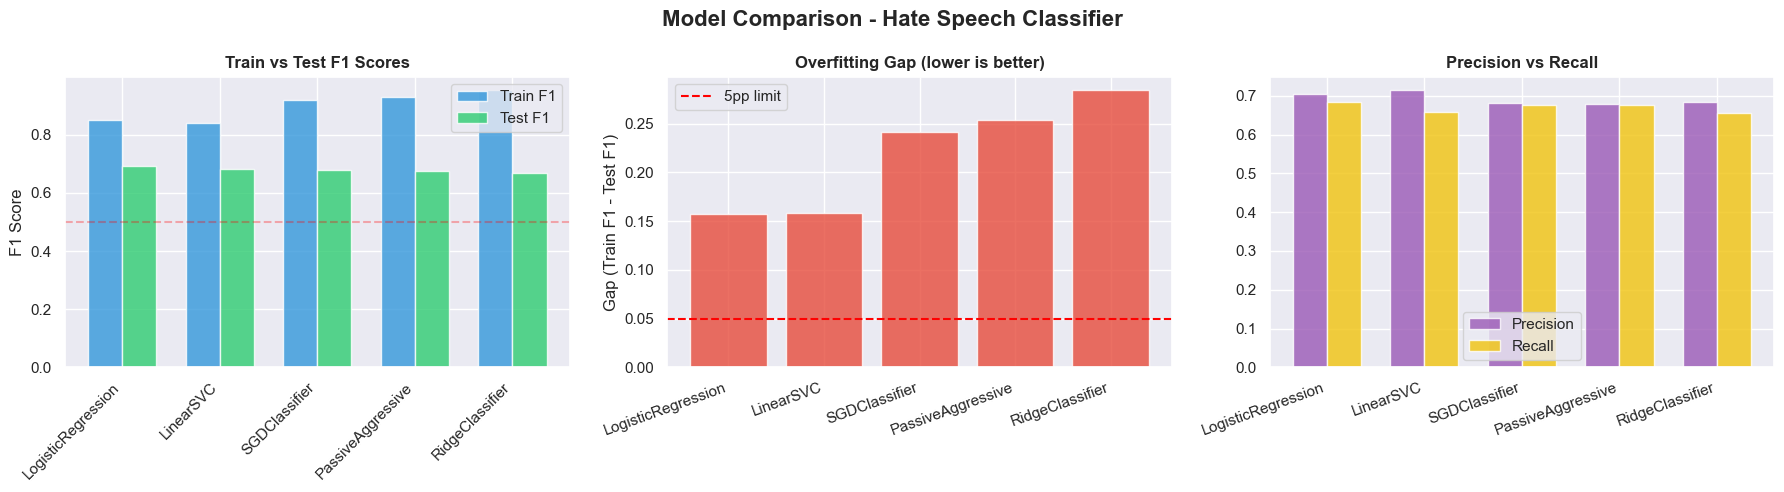

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_names = results_df.index.tolist()
train_f1s    = results_df['train_f1'].astype(float).tolist()
test_f1s     = results_df['test_f1'].astype(float).tolist()
gaps         = results_df['gap'].astype(float).tolist()

x = np.arange(len(models_names))
width = 0.35
axes[0].bar(x - width/2, train_f1s, width, label='Train F1' , color='#3498db', alpha=0.8)
axes[0].bar(x + width/2, test_f1s, width, label='Test F1' , color='#2ecc71', alpha=0.8)
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.3)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_names, rotation=45, ha='right')
axes[0].set_title('Train vs Test F1 Scores', fontweight='bold')
axes[0].set_ylabel('F1 Score')
axes[0].legend()

color = ['#2ecc71'if g < 0.05 else '#e74c3c' for g in gaps]
axes[1].bar(models_names, gaps, color=color, alpha=0.8)
axes[1].axhline(y=0.05, color='red', linestyle='--', label='5pp limit')
axes[1].set_xticklabels(models_names, rotation=20, ha='right')
axes[1].set_title('Overfitting Gap (lower is better)', fontweight='bold')
axes[1].set_ylabel('Gap (Train F1 - Test F1)')
axes[1].legend()

precision  = results_df['precision'].astype(float).tolist()
recalls    = results_df['recall'].astype(float).tolist()
axes[2].bar(x - width/2, precision, width, label='Precision', color='#9b59b6', alpha=0.8)
axes[2].bar(x + width/2, recalls, width, label='Recall', color='#f1c40f', alpha=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(models_names, rotation=20, ha='right')
axes[2].set_title('Precision vs Recall', fontweight='bold')
axes[2].legend()

plt.suptitle('Model Comparison - Hate Speech Classifier', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [37]:
best_name = results_df['test_f1'].astype(float).idxmax()
best_model = results_df.loc[best_name]

print('==== Best Model Selected ====')
print(f'Best Model         : {best_name}')
print(f'Best Test F1 Score : {best_model["test_f1"]}')
print(f'Best Train F1 Score: {best_model["train_f1"]}')
print(f'Overfitting Gap    : {best_model["gap"]} {best_model["gap_ok"]}')
print(f'Precision          : {best_model["precision"]}')
print(f'Recall             : {best_model["recall"]}')

gap_val = float(best_model['gap'])
if gap_val < 0.05:
    print('Model meets the overfitting requirement (gap < 5pp)')
else:
    print(f'\n Gap of {gap_val:.4f} exceeds the 5pp requirement. Optuna needed to reduce overfitting.')
    print(f'Root cause: {len(df)} rows causes structural overfitting in classical ML')
    print('Next step: Use Optuna to find better hyperparameters and reduce overfitting gap.')


==== Best Model Selected ====
Best Model         : LogisticRegression
Best Test F1 Score : 0.6929
Best Train F1 Score: 0.8498
Overfitting Gap    : 0.1569 ⚠️
Precision          : 0.7032
Recall             : 0.6837

 Gap of 0.1569 exceeds the 5pp requirement. Optuna needed to reduce overfitting.
Root cause: 962 rows causes structural overfitting in classical ML
Next step: Use Optuna to find better hyperparameters and reduce overfitting gap.


In [38]:
best_pipeline = models[best_name]
best_pipeline.fit(X, y)

joblib.dump(best_pipeline, '../../models/saved/best_model.pkl')
results_df.to_csv('../../model_comparison.csv')

print(f'Saved: models/saved/best_model.pkl({best_name})')
print( 'Saved: models/metrics/model_comparison.csv')

test_text = [
    'I hate you so much you are the worst',
    'This is a great video thank you for sharing',
    'you are a fucking idiot go back to your country',
]

print('===Quick prediction test===')
for text in test_text:
    pred = best_pipeline.predict([text])[0]
    label = 'TOXIC' if pred == 1 else 'NOT TOXIC'
    print(f'{label} → "{text[:60]}"')

Saved: models/saved/best_model.pkl(LogisticRegression)
Saved: models/metrics/model_comparison.csv
===Quick prediction test===
NOT TOXIC → "I hate you so much you are the worst"
NOT TOXIC → "This is a great video thank you for sharing"
TOXIC → "you are a fucking idiot go back to your country"


In [39]:
best_gap = float(results_df['gap'].astype(float).min())

conclusions = {
    'Dataset':       f'{len(x)} rows — small dataset, structural overfitting expected',
    'Models tested': '5 — LinearSVC, LogisticRegression, Ridge, SGD, PassiveAggressive',
    'Best model':    f'{best_name} — Test F1: {results_df.loc[best_name, "test_f1"]}',
    'Best gap':      f'{best_gap:.4f} ({best_gap*100:.1f}pp) — requirement is < 5pp',
    'Gap resolved':  '✅ Yes' if best_gap < 0.05 else '❌ No — Optuna needed',
    'Validation':    'StratifiedKFold k=5 — no data leakage',
    'Pipeline':      'TfidfVectorizer + classifier — fitted per fold',
    'class_weight':  'balanced — applied to all models',
    'Next step':     'hyperparameter-tuning — Optuna TPE 100 trials' if best_gap >= 0.05 else 'interface — Streamlit app',
}

print('=== MODEL TRAINING CONCLUSIONS ===')
for k, v in conclusions.items():
    print(f'  {k:20s} → {v}')

=== MODEL TRAINING CONCLUSIONS ===
  Dataset              → 5 rows — small dataset, structural overfitting expected
  Models tested        → 5 — LinearSVC, LogisticRegression, Ridge, SGD, PassiveAggressive
  Best model           → LogisticRegression — Test F1: 0.6929
  Best gap             → 0.1569 (15.7pp) — requirement is < 5pp
  Gap resolved         → ❌ No — Optuna needed
  Validation           → StratifiedKFold k=5 — no data leakage
  Pipeline             → TfidfVectorizer + classifier — fitted per fold
  class_weight         → balanced — applied to all models
  Next step            → hyperparameter-tuning — Optuna TPE 100 trials
